# Intel image classification

## Deep Learning Challenge 2

Students:
asdd
qd
qwd

---

In [2]:
import os
import random
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import f1_score, classification_report, confusion_matrix

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

BASE_DIR = os.path.abspath(".")
TRAIN_DIR = os.path.join(BASE_DIR, "data", "seg_train", "seg_train")
VAL_DIR = os.path.join(BASE_DIR, "data", "seg_test", "seg_test")
PRED_DIR = os.path.join(BASE_DIR, "data", "seg_pred", "seg_pred")
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
NUM_CLASSES = len(CLASS_NAMES)

In [4]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


## Part 1 - Dataset setup

In [3]:
paths_to_check = {
    "train": TRAIN_DIR,
    "validation": VAL_DIR,
    "prediction (unlabeled)": PRED_DIR,
}

for label, path in paths_to_check.items():
    ok = os.path.isdir(path)
    print(f"{label}: {'OK' if ok else 'MISSING'} - {path}")

assert os.path.isdir(TRAIN_DIR), "Train folder not found - fix TRAIN_DIR or your data layout."
assert os.path.isdir(VAL_DIR), "Validation folder not found - fix VAL_DIR or your data layout."

# one class - each subfolder
train_subfolders = sorted(
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
)
val_subfolders = sorted(
    d for d in os.listdir(VAL_DIR)
    if os.path.isdir(os.path.join(VAL_DIR, d))
)
print("\nTrain classes:", train_subfolders)
print("Val classes:  ", val_subfolders)

train: OK - /Users/angelakrstevska/ai-ds-master/dl/DeepLearning/Challenge2/data/seg_train/seg_train
validation: OK - /Users/angelakrstevska/ai-ds-master/dl/DeepLearning/Challenge2/data/seg_test/seg_test
prediction (unlabeled): OK - /Users/angelakrstevska/ai-ds-master/dl/DeepLearning/Challenge2/data/seg_pred/seg_pred

Train classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Val classes:   ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Sample images - before preprocessing

One **raw** RGB image per class straight from the training folders (**no** resize, crop, or normalisation). This matches what is on disk; Part 2 then defines how we feed the model.


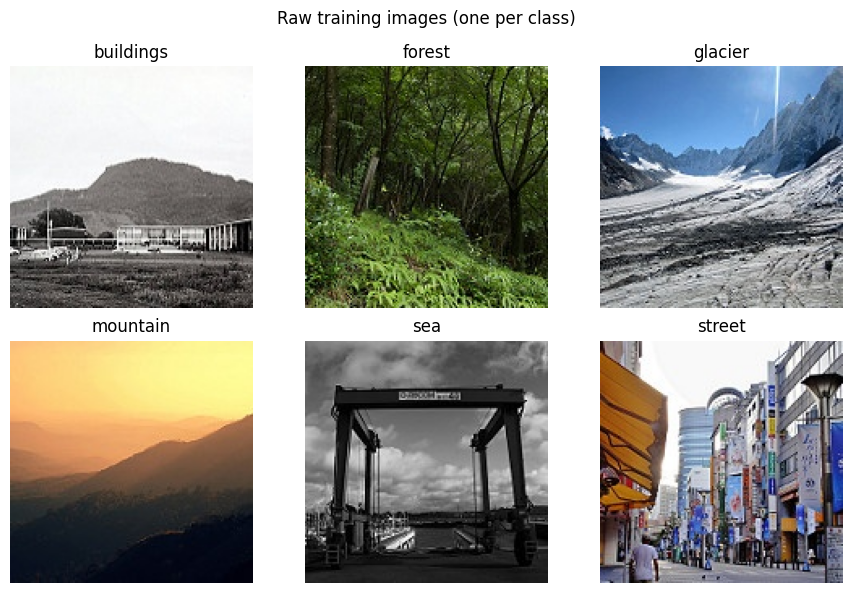

In [4]:
from PIL import Image

class_dirs = sorted(d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d)))
sample_paths = []
for class_name in class_dirs:
    folder = os.path.join(TRAIN_DIR, class_name)
    names = sorted(f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    sample_paths.append((class_name, os.path.join(folder, names[0])))

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, (class_name, pth) in zip(axes.ravel(), sample_paths):
    ax.imshow(Image.open(pth).convert("RGB"))
    ax.set_title(class_name)
    ax.axis("off")
fig.suptitle("Raw training images (one per class)")
plt.tight_layout()
plt.show()


## Part 2 - Preprocessing and augmentation

- **Pixels** - `ToTensor()` scales to **[0, 1]** (/255). We then **normalize** with ImageNet mean/std (usual for CNNs).
- **Training** - **Resize(160)** then **RandomCrop(150)** (small translation / scale jitter vs resizing straight to 150), plus **horizontal flip**, **small rotation**, light **color jitter** - helps **macro F1**.
- **Validation** - **Resize** to **150×150** (same spatial size as training crops), then `ToTensor` + `Normalize` only - **no** random augmentation, so scores are stable and match what we will use in evaluation / `predict.py`.

We will reuse the same validation transform for evaluation and for `predict.py`.

In [5]:
IMAGE_SIZE = 150
TRAIN_RESIZE = 160  # slightly larger than crop so RandomCrop can vary position
BATCH_SIZE = 32
NUM_WORKERS = 0

train_transforms = transforms.Compose([
    transforms.Resize(TRAIN_RESIZE),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

# numeric label to folder name
idx_to_class = {idx: name for name, idx in train_dataset.class_to_idx.items()}

print("Encoded labels: ", train_dataset.class_to_idx)
print("Total train images:", len(train_dataset))
print("Total val images:  ", len(val_dataset))

# Count images per class
train_counts = Counter(label for _, label in train_dataset.samples)
print("\nTrain images per class:")
for class_name in train_dataset.classes:
    idx = train_dataset.class_to_idx[class_name]
    print(f"  {class_name}: {train_counts[idx]}")

val_counts = Counter(label for _, label in val_dataset.samples)
print("\nValidation images per class:")
for class_name in val_dataset.classes:
    idx = val_dataset.class_to_idx[class_name]
    print(f"  {class_name}: {val_counts[idx]}")

Encoded labels:  {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}
Total train images: 14034
Total val images:   3000

Train images per class:
  buildings: 2191
  forest: 2271
  glacier: 2404
  mountain: 2512
  sea: 2274
  street: 2382

Validation images per class:
  buildings: 437
  forest: 474
  glacier: 553
  mountain: 525
  sea: 510
  street: 501


## After preprocessing - what the CNN sees (training side)

The same files as above, passed through `train_transforms` (resize/crop, flips, jitter, **ToTensor**, ImageNet **normalise**). For display we **denormalise** back to roughly \[0, 1\] so colours are visible.

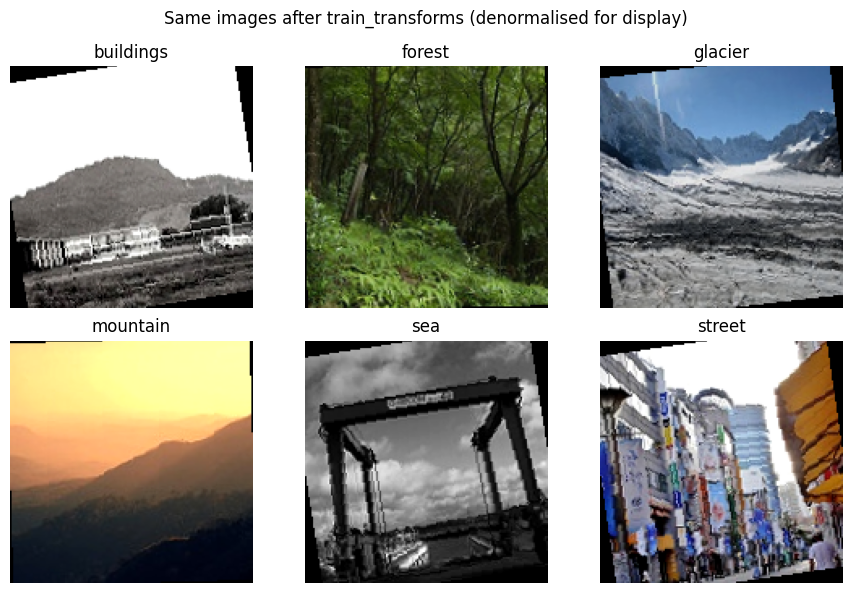

In [6]:

_mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
_std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalise_tensor(x):
    return (x.cpu() * _std + _mean).clamp(0, 1)


fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, (class_name, pth) in zip(axes.ravel(), sample_paths):
    pil = Image.open(pth).convert("RGB")
    x = train_transforms(pil)
    ax.imshow(denormalise_tensor(x).permute(1, 2, 0).numpy())
    ax.set_title(class_name)
    ax.axis("off")
fig.suptitle("Same images after train_transforms (denormalised for display)")
plt.tight_layout()
plt.show()


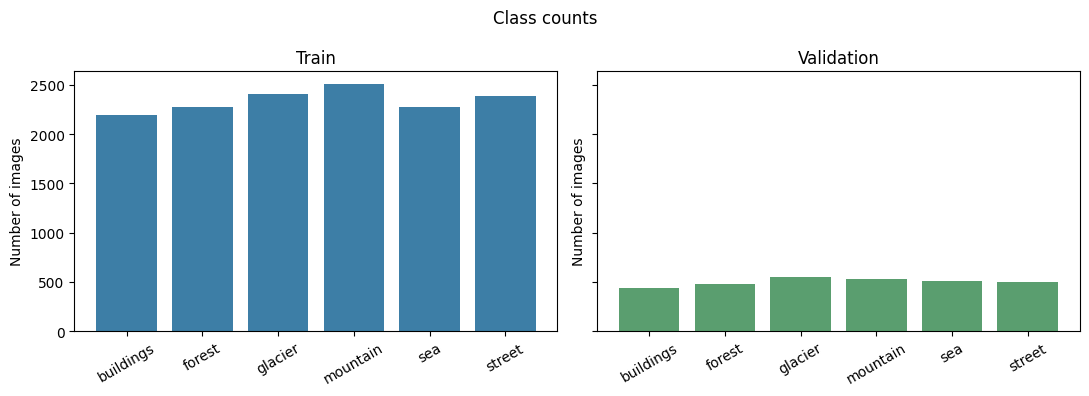

In [ ]:
# Bar plot - images per class
classes = train_dataset.classes
train_heights = [train_counts[train_dataset.class_to_idx[c]] for c in classes]
val_heights = [val_counts[val_dataset.class_to_idx[c]] for c in classes]

fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
ax_train.bar(classes, train_heights, color="#3d7ea6")
ax_train.set_title("Train")
ax_val.bar(classes, val_heights, color="#5a9e6f")
ax_val.set_title("Validation")
for ax in (ax_train, ax_val):
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Number of images")
fig.suptitle("Class counts")
fig.tight_layout()
plt.show()

**Class balance**

The per-class counts are similar, so we start with standard cross-entropy without class weights. The competition uses **macro F1**, so every class counts equally; if one class lags in the **classification report**, we can try **class weights** or stronger augmentation.

## Part 3 - Lean CNN

- **Three conv blocks (32 -> 64 -> 128), 3×3, padding 1** - small kernels, **deeper = more filters**, hierarchical features.
- **Conv -> BatchNorm -> ReLU -> MaxPool(2×2)** each block - BN stabilises training; **MaxPool** downsamples and adds some translation tolerance.
- **Global average pooling (`AdaptiveAvgPool2d(1)` )** - After convs the activation map is **18×18×128**; we **average each channel to one value**, so we get a **128-dimensional vector**. That keeps the first dense layer small and the model **lean** for scoring.
- **Head: Linear(128 -> 256) -> ReLU -> Dropout(0.5) -> Linear(256, 6)** - **Dropout** regularises the classifier; output is **6 logits** (no extra Softmax layer).
- **`CrossEntropyLoss` + logits** - Standard PyTorch; matches **`torch.max`** / macro **F1** evaluation.
- **Xavier init** on **Conv2d** and **Linear** - Reasonable initial scale; biases zero.

In [7]:
class LeanCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), 
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [8]:
model = LeanCNN()
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"LeanCNN trainable parameters: {num_params:,}")
print("After GAP, classifier input size: 128 (one value per channel)")

model.eval()
with torch.no_grad():
    xb, _ = next(iter(train_loader))
    out = model(xb)
    print("Sample output shape:", tuple(out.shape), "<- [batch, num_classes] logits")


LeanCNN trainable parameters: 128,262
After GAP, classifier input size: 128 (one value per channel)
Sample output shape: (32, 6) <- [batch, num_classes] logits


In [11]:
# Here is the code you can use to evaluate your models for both challenges:

from sklearn.metrics import f1_score
import torch

def calculate_f1_score(model, dataloader, device):
    """
    Standardized evaluation for the MSc Deep Learning Competition.
    Uses 'macro' averaging to ensure fairness across imbalanced classes.
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Get the index of the highest prediction
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # The 'macro' setting is the key for the competition ranking
    score = f1_score(all_labels, all_preds, average='macro')
    return score

## Part 4 - Training and evaluation

- **Loss** - `CrossEntropyLoss` on **logits** (6 classes).
- **Optimizer** - **Adam**, **lr = 1e-3**.
- **Scheduler** - `ReduceLROnPlateau` (halve LR when validation loss plateaus, patience 3).
- **Early stopping** - stop if validation loss does not improve for **7** epochs (max **50** epochs).
- **Checkpoint** - **`best_model.pth`** at best validation loss; weights are reloaded for reporting.

Each epoch: train loss, validation loss, validation **macro F1** (`calculate_f1_score`).

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = LeanCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

MAX_EPOCHS = 50
EARLY_STOP = 7 
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

train_losses, val_losses, val_f1s = [], [], []


def run_epoch_train():
    model.train()
    total, n = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item() * inputs.size(0)
        n += inputs.size(0)
    return total / n


@torch.no_grad()
def run_epoch_val_loss():
    model.eval()
    total, n = 0.0, 0
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        logits = model(inputs)
        loss = criterion(logits, labels)
        total += loss.item() * inputs.size(0)
        n += inputs.size(0)
    return total / n


for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss = run_epoch_train()
    va_loss = run_epoch_val_loss()
    scheduler.step(va_loss)
    macro_f1 = calculate_f1_score(model, val_loader, device)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    val_f1s.append(macro_f1)

    print(
        f"Epoch {epoch:02d} | train loss {tr_loss:.4f} | val loss {va_loss:.4f} | val macro F1 {macro_f1:.4f}"
    )

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
        torch.save(best_state, os.path.join(BASE_DIR, "best_model.pth"))
        print("  -> saved best_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= EARLY_STOP:
            print(f"Early stopping (no val improvement for {EARLY_STOP} epochs).")
            break

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

print("\nBest val loss:", best_val_loss)
print("Final val macro F1:", calculate_f1_score(model, val_loader, device))

Device: cuda
Epoch 01 | train loss 1.0623 | val loss 0.8571 | val macro F1 0.6210
  -> saved best_model.pth
Epoch 02 | train loss 0.8279 | val loss 0.7223 | val macro F1 0.7046
  -> saved best_model.pth
Epoch 03 | train loss 0.7589 | val loss 0.8289 | val macro F1 0.6853
Epoch 04 | train loss 0.7014 | val loss 0.6111 | val macro F1 0.7707
  -> saved best_model.pth
Epoch 05 | train loss 0.6592 | val loss 0.6916 | val macro F1 0.7307
Epoch 06 | train loss 0.6268 | val loss 0.6572 | val macro F1 0.7352
Epoch 07 | train loss 0.6063 | val loss 0.5419 | val macro F1 0.8006
  -> saved best_model.pth
Epoch 08 | train loss 0.5755 | val loss 0.7414 | val macro F1 0.6987
Epoch 09 | train loss 0.5574 | val loss 0.7826 | val macro F1 0.7074
Epoch 10 | train loss 0.5424 | val loss 0.7394 | val macro F1 0.7406
Epoch 11 | train loss 0.5411 | val loss 0.6912 | val macro F1 0.7366
Epoch 12 | train loss 0.4710 | val loss 0.5680 | val macro F1 0.7987
Epoch 13 | train loss 0.4662 | val loss 0.4530 | val ma

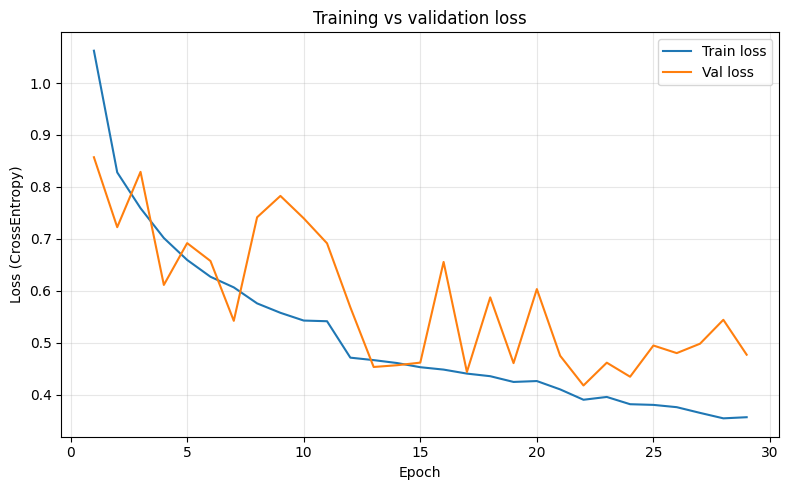

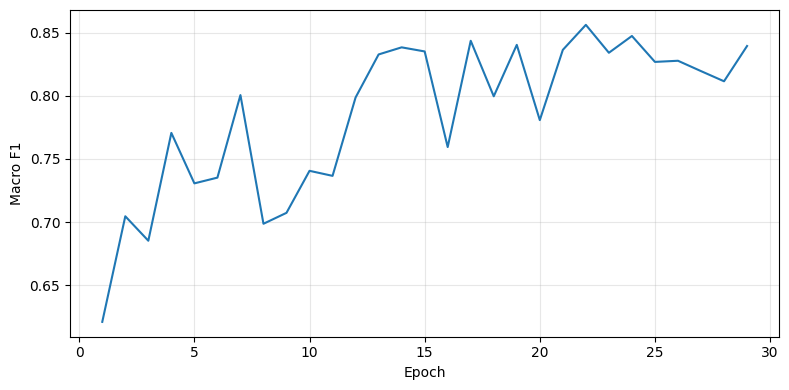

              precision    recall  f1-score   support

   buildings       0.83      0.87      0.85       437
      forest       0.94      0.99      0.96       474
     glacier       0.85      0.75      0.80       553
    mountain       0.82      0.74      0.78       525
         sea       0.82      0.94      0.88       510
      street       0.87      0.87      0.87       501

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.85      3000



In [ ]:
epochs_ran = range(1, len(train_losses) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, train_losses, label="Train loss")
plt.plot(epochs_ran, val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (CrossEntropy)")
plt.title("Train vs val loss (LeanCNN, ReduceLROnPlateau, lr=1e-3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# macro F1 per epoch
plt.figure(figsize=(8, 4))
plt.plot(epochs_ran, val_f1s, label="Val macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation macro F1 per epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Classification report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        _, preds = torch.max(model(inputs), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))

### What we observed

**Outcome (this run):** Training stopped with early stopping (no improvement on validation loss for 7 epochs). The best checkpoint by validation loss had **best val loss approx. 0.417** and after reloading that checkpoint, **validation macro F1 approx 0.856** (approx. **86%** accuracy on `seg_test`).

**Curves:** Training loss decreases smoothly across epochs. Validation loss and macro F1 are noisier (common here because train and val pipelines are not very different). The useful epoch is the one with lowest val loss, not the last epoch.

**Per class:** **Forest** and **sea** tend to be easiest (high F1); **glacier** and **mountain** are relatively harder (more confusion between similar outdoor scenes).

**Next step - Experiment B (below):** Keep the same **LeanCNN** and training recipe (**Adam**, **ReduceLROnPlateau**, same early stopping), but replace **`Resize` + `RandomCrop`** with **`RandomResizedCrop`** on the training set only so the model sees **scale / zoom** variation.


## Part 4b - Experiment B 

**In simple terms:**  The first run learned from images that were **resized** and then **randomly cropped** (always similar scale). In Experiment B we keep the **same network (LeanCNN)** and the **same training setup** (Adam, `ReduceLROnPlateau`, early stopping). We only change **how training images are prepared**: we use **`RandomResizedCrop`**, which picks a random zoom level and a random 150×150 patch. That adds **scale / framing** variety so the model is less sensitive to “how big” the scene is in the frame. **Validation** still uses the usual `val_transforms` / `val_loader`, so metrics stay **comparable** to the first run.

**Output:** training uses a separate DataLoader; the best weights are saved as **`best_model_exp_b.pth`** (vs **`best_model.pth`** for first run).

**Below:** the next cell defines `train_transforms_exp` and `train_loader_exp`. The cell after that shows **one example per class** after those transforms (denormalised for display).


In [9]:
# Stronger augmentation - new DataLoader only
train_transforms_exp = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset_exp = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms_exp)
train_loader_exp = DataLoader(
    train_dataset_exp,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

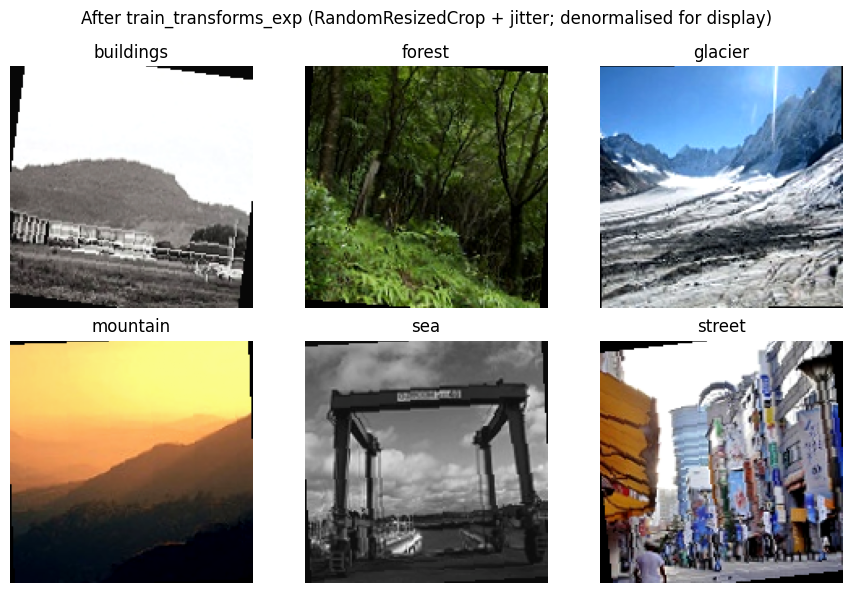

In [10]:
# How Experiment B training images can look (one random view per class)
from PIL import Image
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, (class_name, pth) in zip(axes.ravel(), sample_paths):
    pil = Image.open(pth).convert("RGB")
    x = train_transforms_exp(pil)
    ax.imshow(denormalise_tensor(x).permute(1, 2, 0).numpy())
    ax.set_title(class_name)
    ax.axis("off")
fig.suptitle("After train_transforms_exp (RandomResizedCrop + jitter; denormalised for display)")
plt.tight_layout()
plt.show()


In [ ]:
def train_with_checkpoint(
    model,
    train_dl,
    val_dl,
    checkpoint_filename,
    max_epochs=50,
    early_stop=7,
    lr=1e-3,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses, val_f1s = [], [], []

    def run_epoch_train():
        model.train()
        total, n = 0.0, 0
        for inputs, labels in train_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            logits = model(inputs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total += loss.item() * inputs.size(0)
            n += inputs.size(0)
        return total / n

    @torch.no_grad()
    def run_epoch_val_loss():
        model.eval()
        total, n = 0.0, 0
        for inputs, labels in val_dl:
            inputs = inputs.to(device)
            labels = labels.to(device)
            logits = model(inputs)
            loss = criterion(logits, labels)
            total += loss.item() * inputs.size(0)
            n += inputs.size(0)
        return total / n

    for epoch in range(1, max_epochs + 1):
        tr_loss = run_epoch_train()
        va_loss = run_epoch_val_loss()
        scheduler.step(va_loss)
        macro_f1 = calculate_f1_score(model, val_dl, device)

        train_losses.append(tr_loss)
        val_losses.append(va_loss)
        val_f1s.append(macro_f1)

        print(
            f"Epoch {epoch:02d} | train {tr_loss:.4f} | val {va_loss:.4f} | macro F1 {macro_f1:.4f}"
        )

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            path = os.path.join(BASE_DIR, checkpoint_filename)
            torch.save(best_state, path)
            print(f"  -> saved {checkpoint_filename}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= early_stop:
                print(f"Early stopping ({early_stop} epochs no improvement).")
                break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    print("Best val loss:", best_val_loss)
    print("Final val macro F1:", calculate_f1_score(model, val_dl, device))
    return model, train_losses, val_losses, val_f1s


In [ ]:
#Experiment B - LeanCNN + RandomResizedCrop train
model_b = LeanCNN()
model_b, train_losses_b, val_losses_b, val_f1s_b = train_with_checkpoint(
    model_b,
    train_loader_exp,
    val_loader,
    "best_model_exp_b.pth",
)


Epoch 01 | train 1.0286 | val 0.8502 | macro F1 0.6318
  -> saved best_model_exp_b.pth
Epoch 02 | train 0.8237 | val 0.6712 | macro F1 0.7463
  -> saved best_model_exp_b.pth
Epoch 03 | train 0.7587 | val 0.8746 | macro F1 0.6649
Epoch 04 | train 0.7044 | val 0.7909 | macro F1 0.6978
Epoch 05 | train 0.6674 | val 0.5489 | macro F1 0.7933
  -> saved best_model_exp_b.pth
Epoch 06 | train 0.6382 | val 0.6210 | macro F1 0.7747
Epoch 07 | train 0.6220 | val 0.4994 | macro F1 0.8163
  -> saved best_model_exp_b.pth
Epoch 08 | train 0.5954 | val 0.5786 | macro F1 0.7620
Epoch 09 | train 0.5718 | val 0.5426 | macro F1 0.8042
Epoch 10 | train 0.5592 | val 0.5582 | macro F1 0.7892
Epoch 11 | train 0.5454 | val 0.6730 | macro F1 0.7712
Epoch 12 | train 0.4900 | val 0.4302 | macro F1 0.8431
  -> saved best_model_exp_b.pth
Epoch 13 | train 0.4777 | val 0.4350 | macro F1 0.8396
Epoch 14 | train 0.4681 | val 0.4851 | macro F1 0.8220
Epoch 15 | train 0.4515 | val 0.4916 | macro F1 0.8250
Epoch 16 | trai

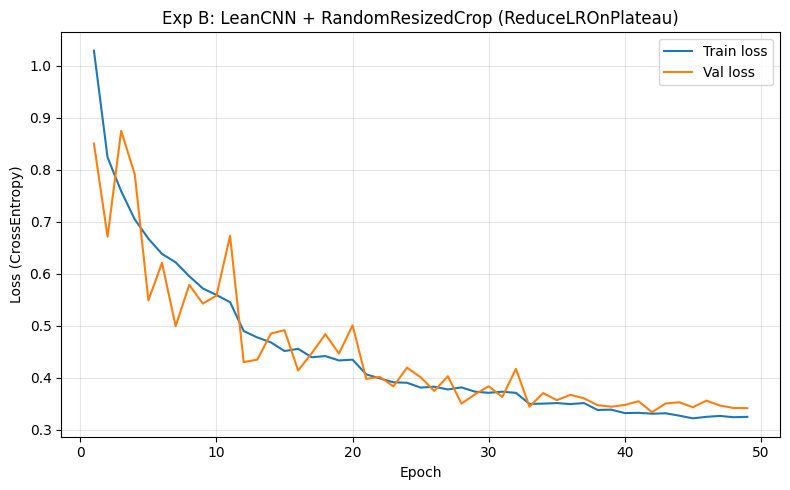

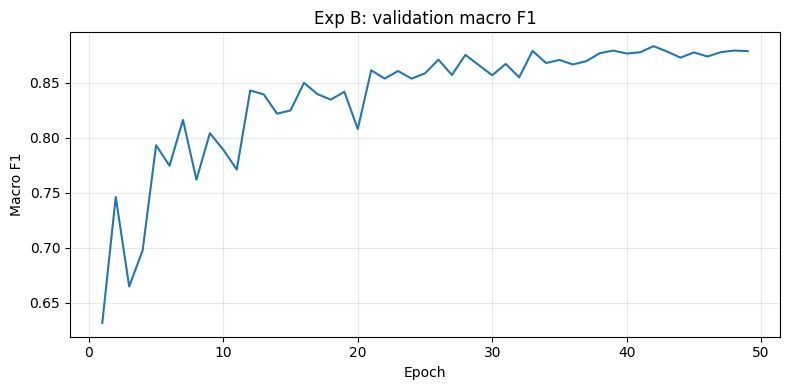

              precision    recall  f1-score   support

   buildings       0.86      0.87      0.86       437
      forest       0.96      0.99      0.97       474
     glacier       0.84      0.85      0.85       553
    mountain       0.84      0.81      0.83       525
         sea       0.91      0.90      0.91       510
      street       0.88      0.89      0.89       501

    accuracy                           0.88      3000
   macro avg       0.88      0.88      0.88      3000
weighted avg       0.88      0.88      0.88      3000



In [ ]:
epochs_b = range(1, len(train_losses_b) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_b, train_losses_b, label="Train loss")
plt.plot(epochs_b, val_losses_b, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (CrossEntropy)")
plt.title("Exp B: LeanCNN + RandomResizedCrop (ReduceLROnPlateau)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_b, val_f1s_b, label="Val macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Exp B: validation macro F1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_b.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        _, preds = torch.max(model_b(inputs), 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))


### Experiment B - what we observed

**Outcome:** Training ran until **early stopping** (validation loss did not improve for 7 epochs; last epoch shown was **49**). The best checkpoint by validation loss has **best val loss  approx. 0.334**. After reloading that checkpoint, **validation macro F1 approx. 0.883** and **accuracy approx. 0.88** on `seg_test` (3000 images).

**Compared to the first run:** Macro F1 moved from about **0.86** to about **0.88**, so **Experiment B** is clearly stronger on this split. The change we tested was only **training augmentation** (`RandomResizedCrop` + same jitter/flip/rotation); **validation** still used `val_transforms`, so the comparison is fair.

**Curves:** Training loss decreases smoothly. Validation loss and macro F1 jump around more than in Run A; that is normal when training uses **random scale/crop** but validation uses **fixed** resizing.

**Per class (validation):** **Forest** is easiest (F1 approx. 0.97). **Mountain** is relatively hardest (F1 approx. 0.83); **glacier** vs **mountain** remains the main source of confusion.


## Chosen model

**Selected run:** **Experiment B** (Part 4b, same **LeanCNN**, training with **`RandomResizedCrop`** and the stronger augmentation pipeline). Checkpoint: **`best_model_exp_b.pth`**.

**Parameters:** **128,262** trainable weights (counted in Part 3 for `LeanCNN` - unchanged between Run A and Experiment B).

**Performance:** On the held-out validation set (`seg_test`), **validation macro F1 approx. 0.883** (approx. **88.3%**) with the best-by-val-loss weights loaded (see Experiment B training output above).
